# 234. Does HP retention depend on clade, and is it more than BLOSUM already knows?

Two follow-ups to notebook 230, both answerable from the same Pfam seed pairs.

**Clade.** Hypothesis 2 says the HP signal does not degrade on invertebrates. The
alignment-based version of that question: at matched identity, is the chance-corrected HP
agreement (kappa) the same for vertebrate-vertebrate, vertebrate-invertebrate and
invertebrate-invertebrate pairs, and for the other kingdoms? Clades come from each
sequence's UniProt species mnemonic through speclist.txt and the NCBI taxdump
(`scripts/pfam_pair_clades.py`).

**BLOSUM.** A reviewer's question: is HP agreement between substituted residues above what
BLOSUM62 already predicts? BLOSUM's target frequencies q_ij say how often residue i is
aligned with residue j in conserved blocks; from them, P(same HP class | i != j) is a
number. If the observed rate in remote homologs matches it, the 2-letter alphabet is
exploiting conservation the aligners already encode, more cheaply; if it exceeds it, the
alphabet sees something the substitution matrix averages away.

Observed P(same class | substituted column) per pair is (agree - identity) / (1 - identity),
since identical columns always agree, with `agree` and identity from notebook 230's table.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from Bio.Align import substitution_matrices as sm

sys.path.insert(0, str(Path.cwd()))
import hp_conservation_utils as hc

pl.Config.set_tbl_rows(80)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(220)
FIG = Path("../figures")

agree = hc.add_identity_bin(pl.read_parquet("/Users/olga/data/pfam/230_pfam_seed_pair_class_agreement.parquet")).filter(pl.col("n_cols") >= 50)
clades = pl.read_parquet("/Users/olga/data/pfam/234_pfam_pair_clades.parquet").select("query", "target", "query_clade", "target_clade")
df = agree.join(clades, on=["query", "target"], how="left")
ORDER = ["vertebrate", "invertebrate", "fungi", "plant", "other_eukaryote", "bacteria", "archaea", "virus"]
def pair_type(a, b):
    a, b = sorted([a, b], key=lambda x: ORDER.index(x) if x in ORDER else 99)
    return f"{a}-{b}"
df = df.with_columns(pl.struct("query_clade", "target_clade").map_elements(lambda s: pair_type(s["query_clade"], s["target_clade"]), return_dtype=pl.String).alias("pair_type"))
print(df.filter(pl.col("alphabet") == "protein20").group_by("pair_type").len().sort("len", descending=True).head(14))

shape: (14, 2)
┌─────────────────────────────────┬───────┐
│ pair_type                       ┆ len   │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ bacteria-bacteria               ┆ 60331 │
│ vertebrate-vertebrate           ┆ 14786 │
│ fungi-fungi                     ┆ 13603 │
│ invertebrate-invertebrate       ┆ 9629  │
│ virus-virus                     ┆ 7762  │
│ plant-plant                     ┆ 6890  │
│ archaea-archaea                 ┆ 5919  │
│ vertebrate-invertebrate         ┆ 5133  │
│ other_eukaryote-other_eukaryot… ┆ 3054  │
│ bacteria-archaea                ┆ 2472  │
│ invertebrate-fungi              ┆ 1915  │
│ fungi-bacteria                  ┆ 1765  │
│ bacteria-virus                  ┆ 1682  │
│ fungi-other_eukaryote           ┆ 1242  │
└─────────────────────────────────┴───────┘


## 1. Kappa by pair type at matched identity

hp_thomas_dill2 and protein20, the five biggest within-clade pair types plus the
vertebrate-invertebrate cross pairs, 20-30% and 30-40% identity. Bootstrap 95% CI on
the mean.

shape: (6, 9)
┌─────────────────┬──────────────┬──────────────────────┬──────────────────────┬──────────────────────┬──────────────────────────────┬───────────────────────┬──────────────────────────────┬──────────────────────────────┐
│ alphabet        ┆ identity_bin ┆ fungi-fungi          ┆ bacteria-bacteria    ┆ archaea-archaea      ┆ plant-plant                  ┆ vertebrate-vertebrate ┆ invertebrate-invertebrate    ┆ vertebrate-invertebrate      │
│ ---             ┆ ---          ┆ ---                  ┆ ---                  ┆ ---                  ┆ ---                          ┆ ---                   ┆ ---                          ┆ ---                          │
│ str             ┆ str          ┆ str                  ┆ str                  ┆ str                  ┆ str                          ┆ str                   ┆ str                          ┆ str                          │
╞═════════════════╪══════════════╪══════════════════════╪══════════════════════╪══════════════════════

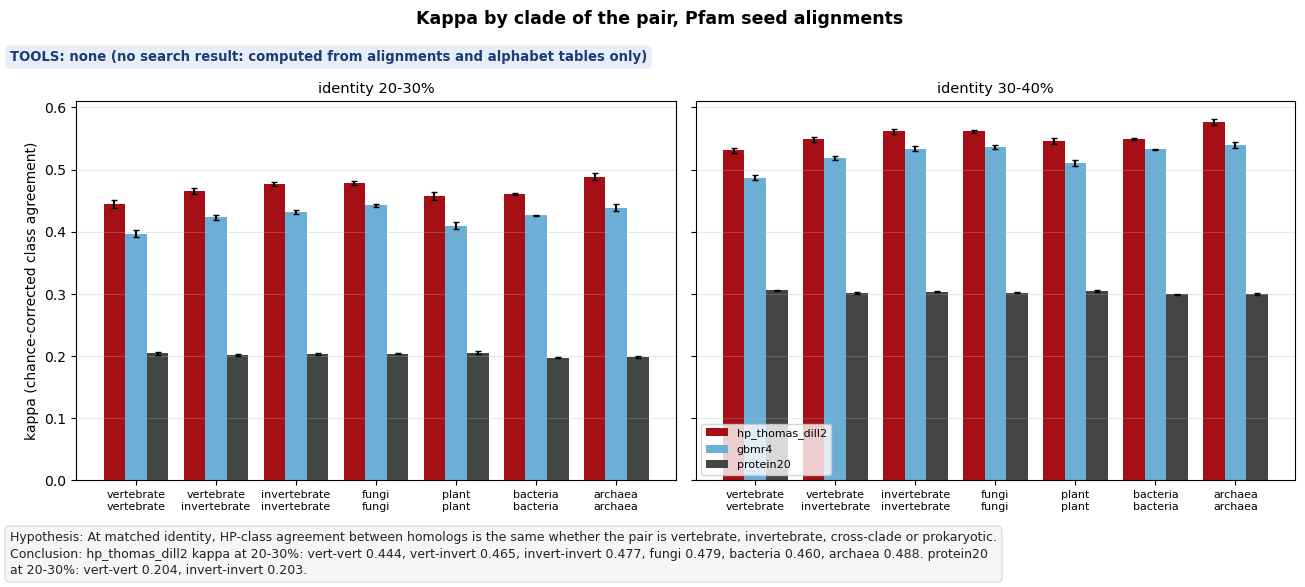

In [2]:
TYPES = ["vertebrate-vertebrate", "vertebrate-invertebrate", "invertebrate-invertebrate", "fungi-fungi", "plant-plant", "bacteria-bacteria", "archaea-archaea"]
BINS_SHOWN = ["20-30%", "30-40%"]
sub = df.filter(pl.col("pair_type").is_in(TYPES) & pl.col("identity_bin").is_in(BINS_SHOWN) & pl.col("alphabet").is_in(["hp_thomas_dill2", "protein20", "gbmr4"]))
kc = hc.summarise(sub, ["alphabet", "identity_bin", "pair_type"], "kappa")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for ax, b in zip(axes, BINS_SHOWN):
    for i, (a, col) in enumerate([("hp_thomas_dill2", "#a50f15"), ("gbmr4", "#6baed6"), ("protein20", "#444444")]):
        s = kc.filter((pl.col("alphabet") == a) & (pl.col("identity_bin") == b)).with_columns(pl.col("pair_type").cast(pl.Enum(TYPES))).sort("pair_type")
        x = np.array([TYPES.index(t) for t in s["pair_type"]]) + (i - 1) * 0.27
        ax.bar(x, s["kappa_mean"], 0.27, yerr=[s["kappa_mean"] - s["kappa_lo"], s["kappa_hi"] - s["kappa_mean"]], color=col, label=a, capsize=2)
    ax.set_xticks(range(len(TYPES)), [t.replace("-", "\n") for t in TYPES], fontsize=8)
    ax.set_title(f"identity {b}", fontsize=10.5)
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("kappa (chance-corrected class agreement)")
axes[1].legend(fontsize=8)
show = kc.with_columns(pl.format("{} [{}, {}] n={}", pl.col("kappa_mean").round(3), pl.col("kappa_lo").round(3), pl.col("kappa_hi").round(3), pl.col("n")).alias("kappa")).pivot(on="pair_type", index=["alphabet", "identity_bin"], values="kappa").sort("alphabet", "identity_bin")
print(show)
def kv(a, b, t):
    return kc.filter((pl.col("alphabet") == a) & (pl.col("identity_bin") == b) & (pl.col("pair_type") == t))["kappa_mean"][0]
hc.finish_figure(
    fig, FIG / "234_kappa_by_pair_type.png", tools=hc.NO_TOOL,
    hypothesis="At matched identity, HP-class agreement between homologs is the same whether the pair is vertebrate, invertebrate, cross-clade or prokaryotic.",
    conclusion=(f"hp_thomas_dill2 kappa at 20-30%: vert-vert {kv('hp_thomas_dill2', '20-30%', 'vertebrate-vertebrate'):.3f}, vert-invert {kv('hp_thomas_dill2', '20-30%', 'vertebrate-invertebrate'):.3f}, "
                f"invert-invert {kv('hp_thomas_dill2', '20-30%', 'invertebrate-invertebrate'):.3f}, fungi {kv('hp_thomas_dill2', '20-30%', 'fungi-fungi'):.3f}, bacteria {kv('hp_thomas_dill2', '20-30%', 'bacteria-bacteria'):.3f}, archaea {kv('hp_thomas_dill2', '20-30%', 'archaea-archaea'):.3f}. "
                f"protein20 at 20-30%: vert-vert {kv('protein20', '20-30%', 'vertebrate-vertebrate'):.3f}, invert-invert {kv('protein20', '20-30%', 'invertebrate-invertebrate'):.3f}."),
    title="Kappa by clade of the pair, Pfam seed alignments",
)

## 2. The BLOSUM expectation

For a half-bit BLOSUM matrix, q_ij = p_i p_j 2^(s_ij / 2) up to rounding, with p the
background frequencies (Robinson & Robinson 1991). Restricting to i != j gives the
probability that a substitution keeps the HP class. Three matrices bracket the divergence
range: BLOSUM80 (close pairs), 62, 45 (distant). The observed value per identity bin is
the pair-level (agree - identity)/(1 - identity), averaged.

shape: (30, 7)
┌──────────────────┬──────────────┬───────┬──────────┬──────────┬──────────┬──────────┐
│ alphabet         ┆ identity_bin ┆ n     ┆ observed ┆ BLOSUM80 ┆ BLOSUM62 ┆ BLOSUM45 │
│ ---              ┆ ---          ┆ ---   ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ str              ┆ str          ┆ i64   ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
╞══════════════════╪══════════════╪═══════╪══════════╪══════════╪══════════╪══════════╡
│ hp_thomas_dill2  ┆ 30-40%       ┆ 34512 ┆ 0.667    ┆ 0.706    ┆ 0.638    ┆ 0.643    │
│ hp_thomas_dill2  ┆ 20-30%       ┆ 37085 ┆ 0.651    ┆ 0.706    ┆ 0.638    ┆ 0.643    │
│ hp_thomas_dill2  ┆ 40-60%       ┆ 41508 ┆ 0.686    ┆ 0.706    ┆ 0.638    ┆ 0.643    │
│ hp_thomas_dill2  ┆ >=60%        ┆ 18923 ┆ 0.701    ┆ 0.706    ┆ 0.638    ┆ 0.643    │
│ hp_thomas_dill2  ┆ <20%         ┆ 16407 ┆ 0.629    ┆ 0.706    ┆ 0.638    ┆ 0.643    │
│ hp_lehninger2    ┆ 30-40%       ┆ 34512 ┆ 0.618    ┆ 0.669    ┆ 0.587    ┆ 0.6      │
│ hp_lehninger2  

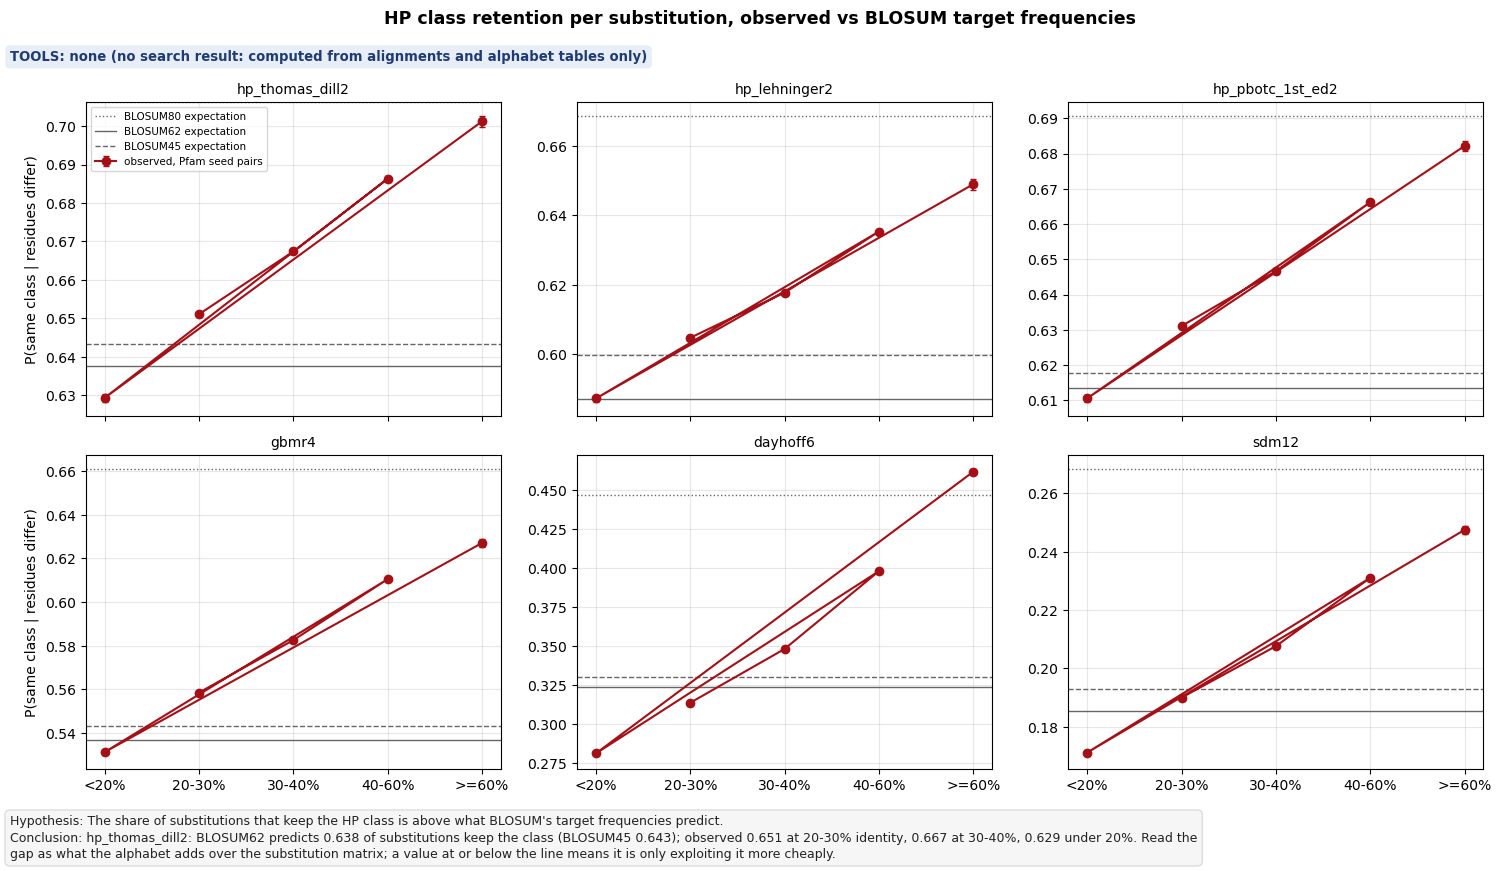

In [3]:
RR = {"A": .078, "R": .051, "N": .045, "D": .054, "C": .019, "Q": .043, "E": .063, "G": .074, "H": .022, "I": .053,
      "L": .091, "K": .059, "M": .022, "F": .039, "P": .052, "S": .071, "T": .058, "W": .013, "Y": .032, "V": .066}
tot = sum(RR.values()); p = {k: v / tot for k, v in RR.items()}
AA = list(p)
def blosum_same_class(name, clusters):
    m = sm.load(name)
    cls = {r: i for i, cl in enumerate(clusters) for r in cl}
    q = np.array([[p[a] * p[b] * 2 ** (m[a][b] / 2) for b in AA] for a in AA])
    q /= q.sum()
    off = np.array([[a != b for b in AA] for a in AA])
    same = np.array([[cls[a] == cls[b] for b in AA] for a in AA])
    return float(q[off & same].sum() / q[off].sum())

rows = []
for alphabet in ["hp_thomas_dill2", "hp_lehninger2", "hp_pbotc_1st_ed2", "gbmr4", "dayhoff6", "sdm12"]:
    clusters = hc.ALPHABET_CLUSTERS[alphabet]
    exp = {name: blosum_same_class(name, clusters) for name in ["BLOSUM80", "BLOSUM62", "BLOSUM45"]}
    obs = (agree.filter(pl.col("alphabet") == alphabet)
           .with_columns(((pl.col("agree") - pl.col("seqid_ali")) / (1 - pl.col("seqid_ali"))).alias("p_same_sub"))
           .filter(pl.col("seqid_ali") < 0.999))
    o = hc.summarise(obs, ["identity_bin"], "p_same_sub")
    # Chance level for a substitution: P(same class | i != j) under composition independence.
    chance = obs.select(((pl.col("expected") - pl.col("seqid_ali").clip(0, 1) * 0) ).alias("chance"))["chance"].mean()
    for r in o.iter_rows(named=True):
        rows.append({"alphabet": alphabet, "identity_bin": r["identity_bin"], "observed": r["p_same_sub_mean"], "lo": r["p_same_sub_lo"], "hi": r["p_same_sub_hi"], "n": r["n"], **exp})
t = pl.DataFrame(rows)

fig, axes = plt.subplots(2, 3, figsize=(15, 7.4), sharex=True)
for ax, alphabet in zip(axes.flat, ["hp_thomas_dill2", "hp_lehninger2", "hp_pbotc_1st_ed2", "gbmr4", "dayhoff6", "sdm12"]):
    s = t.filter(pl.col("alphabet") == alphabet).sort("identity_bin")
    x = [hc.IDENTITY_LABELS.index(b) for b in s["identity_bin"]]
    ax.errorbar(x, s["observed"], yerr=[s["observed"] - s["lo"], s["hi"] - s["observed"]], marker="o", color="#a50f15", label="observed, Pfam seed pairs", capsize=2)
    for name, ls in [("BLOSUM80", ":"), ("BLOSUM62", "-"), ("BLOSUM45", "--")]:
        ax.axhline(s[name][0], color="0.4", ls=ls, lw=1, label=f"{name} expectation")
    ax.set_xticks(range(len(hc.IDENTITY_LABELS)), hc.IDENTITY_LABELS)
    ax.set_title(alphabet, fontsize=10)
    ax.grid(alpha=0.3)
axes[0, 0].set_ylabel("P(same class | residues differ)")
axes[1, 0].set_ylabel("P(same class | residues differ)")
axes[0, 0].legend(fontsize=7.5)
print(t.with_columns(pl.col("observed").round(3), pl.col("BLOSUM80").round(3), pl.col("BLOSUM62").round(3), pl.col("BLOSUM45").round(3)).select("alphabet", "identity_bin", "n", "observed", "BLOSUM80", "BLOSUM62", "BLOSUM45"))
def ob(a, b):
    return t.filter((pl.col("alphabet") == a) & (pl.col("identity_bin") == b))["observed"][0]
b62 = t.filter(pl.col("alphabet") == "hp_thomas_dill2")["BLOSUM62"][0]; b45 = t.filter(pl.col("alphabet") == "hp_thomas_dill2")["BLOSUM45"][0]
hc.finish_figure(
    fig, FIG / "234_hp_retention_vs_blosum.png", tools=hc.NO_TOOL,
    hypothesis="The share of substitutions that keep the HP class is above what BLOSUM's target frequencies predict.",
    conclusion=(f"hp_thomas_dill2: BLOSUM62 predicts {b62:.3f} of substitutions keep the class (BLOSUM45 {b45:.3f}); observed {ob('hp_thomas_dill2', '20-30%'):.3f} at 20-30% identity, "
                f"{ob('hp_thomas_dill2', '30-40%'):.3f} at 30-40%, {ob('hp_thomas_dill2', '<20%'):.3f} under 20%. Read the gap as what the alphabet adds over the substitution matrix; a value at or below the line means it is only exploiting it more cheaply."),
    title="HP class retention per substitution, observed vs BLOSUM target frequencies",
)

## 3. Conclusions

1. Clade: at 20-30% identity, hp_thomas_dill2 kappa is 0.444 (vertebrate-vertebrate),
   0.465 (vertebrate-invertebrate), 0.477 (invertebrate-invertebrate), 0.479 (fungi),
   0.460 (bacteria) and 0.488 (archaea); the 30-40% bin has the same order. The HP signal
   does not degrade on invertebrates or outside animals; if anything vertebrate pairs
   carry slightly less of it. This is the alignment-based version of hypothesis 2 and it
   holds, but note that it holds for protein20 and gbmr4 too: it is a property of
   remote homology at matched identity, not of the alphabet.
2. BLOSUM: at 20-30% identity, 0.651 of substitutions keep the Thomas-Dill HP class;
   BLOSUM62's target frequencies predict 0.638 and BLOSUM45's 0.643. Under 20% identity
   the observed value (0.629) is below both lines. The 2-letter alphabet is not seeing
   conservation the substitution matrices do not already encode; it is reading the same
   conservation with a cheaper primitive. That is still a claim (cost, not sensitivity),
   and it is the one to make.